# 实验二、使用朴素贝叶斯决策进行分类


姓名：王智颍

学号：3238507069

班级：3班

日期：2025.12.12



本实验主要分为以下两个部分：

1. 从头实现贝叶斯决策算法，并运用于MNIST手写数字图片识别上

2. 调用 scipy 的 GaussianNB 库函数，进行软件缺陷预测，并给出评价模型指标


## 1. MNIST手写数字识别


MNIST 数据库是一个大型手写数字数据库（包含0-9十个数字），包含 60,000 张训练图像和 10,000 张测试图像，通常用于训练各种图像处理系统。训练数据集取自美国人口普查局员工，而测试数据集取自美国高中生。所有的手写数字图片的分辨率为`28*28`, 每一个维度上的取值范围为`[0~255]`。

In [54]:
# 导入库文件
import numpy as np
from matplotlib import pyplot as plt

In [55]:
# 导入数据
mnistTrain = np.load("dataset/mnistTrain5000.npz")
mnistTest = np.load("dataset/mnistTest500.npz")

trainData, trainLabel = mnistTrain['data'], mnistTrain['label'].astype(int)
testData, testLabel = mnistTest['data'], mnistTest['label'].astype(int)

print(f'训练样本数目：{trainData.shape[0]}. 测试样本数目：{testData.shape[0]}.')
print(f'每一个样本维度:{trainData[0].shape}')

训练样本数目：5000. 测试样本数目：500.
每一个样本维度:(28, 28)


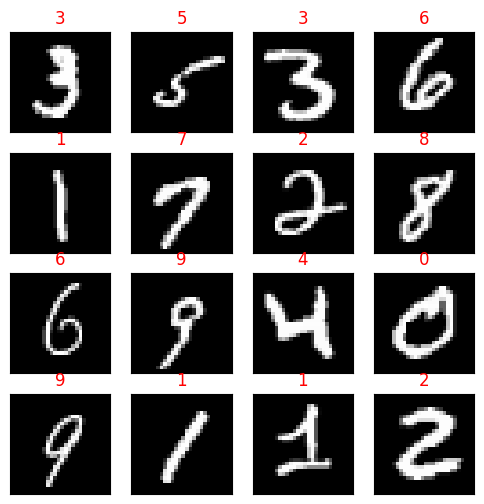

In [56]:
# 绘制图形 与 对应的标签
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
startInd = 10
for row in range(4):
    for col in range(4):
        axes[row, col].imshow(trainData[startInd + 4*row+col], cmap='gray', vmin=0, vmax=255)
        axes[row, col].set_title(trainLabel[startInd + 4*row+col, 0], color='red')
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

#### 1.1 使用朴素贝叶斯分类算法进行MNIST手写数字图片分类

朴素贝叶斯分类步骤：

- (1) 估计先验概率 $P(c)$

- (2) 假设各特征变量之间是条件独立的，估计类条件概率 $P(x_{i} \mid c)$, 其中 $x_{i}$ 表示第 $i$ 维度的特征

- (3) 用朴素贝叶斯公式估计后验概率 
$P(c \mid x)=P(c \mid x_{1}, x_{2}, \ldots, x_{p}) = P(c)P(x_{1}, x_{2}, \ldots, x_{p} \mid c) / P(x) = P(c)P(x_{1}\mid c)P(x_{2}\mid c) \ldots P(x_{p}\mid c) / P(x)$

- (4) 寻找后验概率最大的类为预测的类别。 $h(x)=\mathop{\arg\max}\limits_{c} P(c|x)$


为了简化此实验，我们将每一张图片上的`0~255`的数据分为简单的`0, 1`两种情况，方便估计类条件概率。


In [57]:
# 将数据重新映射到 0 / 1 两种特征值

## TODO: 
## ------------- 请在以下填入代码 ------------- ##
## 将 trainData 映射为 0/1 两种情况 
trainData_bin = trainData.copy()
trainData_bin[trainData_bin < 128] = 0
trainData_bin[trainData_bin >= 128] = 1

## TODO:
## ------------- 请在以下填入代码 ------------- ##
testData_bin = testData.copy()
testData_bin[testData_bin < 128] = 0  
testData_bin[testData_bin >= 128] = 1
## 将 testData 映射为 0/1 两种情况 
# testData
# testData

### 1.1 使用平滑估计

在根据数据估计先验概率$P(c)$和类条件概率$P(x_{i}|c)$时，如果这个类/特征完全没有出现过，此对应的概率就会被设置为0，最终会影响后验概率$P(c|x)$的计算。

因此，本实验采用平滑估计的方法，其计算公式如下

$$[\hat\theta_{jc}]_{\alpha} = \frac{\sum_{i=1}^{n} I(y_i = c) I(x_{i\alpha} = j) + l}{\sum_{i=1}^{n} I(y_i = c) + l \cdot c}$$

其中$[\hat\theta_{jc}]_{\alpha}$为待预测的参数，$\sum_{i = 1}^{n} I(y_i = c) I(x_{i\alpha}=j)$表示特征$j$在$c$类中出现的次数, $\sum_{i = 1}^{n} I(y_i = c)$
 $l$是平滑参数(Smoothing parameter)，一般取为 $1$, $c$表示为类的总个数。

In [58]:
# 1.1 求解先验概率 p(y)

yClasses, countsPerClass = np.unique(trainLabel.flatten(), return_counts=True)

## TODO:
## ------------- 请在以下填入代码 ------------- ##
## 求解先验概率 p(y)（平滑估计）
l = 1  # 平滑参数（实验要求取1）
n_classes = len(yClasses)  # 类别总个数（0-9，共10个）
total_samples = trainLabel.size  # 总训练样本数

# 平滑估计先验概率：(类别样本数 + l) / (总样本数 + l * 类别总数)
priorList = (countsPerClass + l) / (total_samples + l * n_classes)


In [59]:
# 1.2 求解类条件概率 p(x=1|y)
conditionProbList = []
xjClasses = np.unique(trainData_bin).tolist()  # 用二值化数据获取特征取值[0,1]
l = 1.0  # 平滑参数（与实验公式的l一致）

## TODO:
## ------------- 请在以下填入代码 ------------- ##
for c in yClasses:                              # y 的类别 (0, 1, 2, ..., 9)
    # 关键修正：用二值化后的trainData_bin
    classData = trainData_bin[trainLabel.flatten() == c].reshape(-1, 28*28)
    xjCondProbList = []                         # p(x=j | y = c)

    for jdx in range(classData.shape[1]):
        # 统计类别c下第jdx个特征为1的样本数
        count_x1 = np.sum(classData[:, jdx] == 1)
        # 类别c的总样本数
        count_c = classData.shape[0]
        # 拉普拉斯平滑计算条件概率（贴合实验公式）
        prob = (count_x1 + l) / (count_c + l * len(xjClasses))
        xjCondProbList.append(prob)
    conditionProbList.append(xjCondProbList)
# 转换为数组方便后续计算
conditionProbList = np.array(conditionProbList)

### 1.2 计算后验概率 $P(y|x_{i})$, 检查 训练集 与 测试集 上的表现

计算贝叶斯后验概率，完成朴素贝叶斯的MNIST手写数字分类器的预测，并绘制几个手写识别结果。

In [60]:
# 1.2.1 计算 训练集 后验概率 P(y|xi)
trainPredList = []

## 计算 训练集 后验概率 P(y|xi)
for ind in range(trainData_bin.shape[0]):  # 改用二值化数据的维度
    tData = trainData_bin[ind].flatten()   # 核心修正：用二值化后的trainData_bin
    hxList = []
    # 对每一个类c计算后验概率
    for c, prior, condProb in zip(yClasses, priorList, conditionProbList):
        hx = np.log(prior)
        
        ## TODO:
        ## ------------- 请在以下填入代码 ------------- ##
        # 计算对数类条件概率密度 ln p(x=1 | y=c) + ln p(x=0 | y=c)
        # 遍历每个特征维度，累加对数条件概率
        for jdx in range(len(condProb)):
            x_j = tData[jdx]  # 当前样本的第jdx个特征值（0或1）
            if x_j == 1:
                # 特征为1时，取ln(p(x_j=1|y=c))
                hx += np.log(condProb[jdx])
            else:
                # 特征为0时，取ln(1 - p(x_j=1|y=c))
                hx += np.log(1 - condProb[jdx])
        # 将当前类别的后验概率对数加入列表
        hxList.append(hx)
        
    # 最大后验概率决策
    predInd = np.argmax(hxList)
    trainPredList.append(predInd)

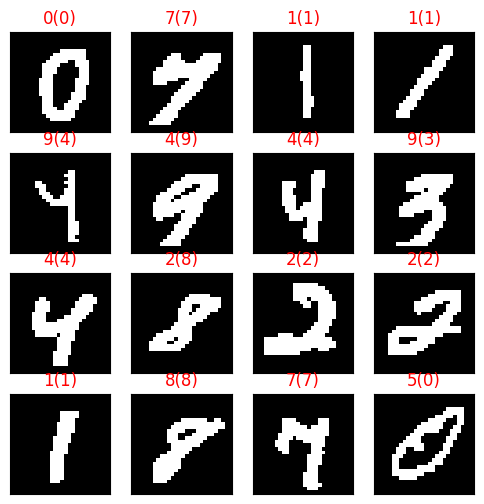

In [61]:
# 绘制图形 与 预测的标签
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
startInd = 1000
for row in range(4):
    for col in range(4):
        axes[row, col].imshow(trainData[startInd + 4*row+col], cmap='gray', vmin=0, vmax=1)
        label = trainLabel[startInd + 4*row+col].item()
        axes[row, col].set_title(f'{trainPredList[startInd + 4*row+col]}({label})', color='red')
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

In [62]:
# 1.2.2 计算 测试集 后验概率 P(y|xi)
testPredList = []

## TODO:
## ------------- 请在以下填入代码 ------------- ##
## 计算 测试集 后验概率 P(y|xi)
for ind in range(testData_bin.shape[0]):  # 修正1：改用二值化数据的维度
    tData = testData_bin[ind].flatten()   # 修正2：用二值化后的testData_bin
    hxList = []                      # 存储每个类别的后验概率对数
    
    # 对每一个类别c计算后验概率对数
    for c, prior, condProb in zip(yClasses, priorList, conditionProbList):
        hx = np.log(prior)  # 先验概率的对数
        
        # 累加每个特征的对数条件概率
        for jdx in range(len(condProb)):
            x_j = tData[jdx]  # 当前特征值（0/1，二值化后仅这两个值）
            if x_j == 1:
                hx += np.log(condProb[jdx])  # 特征为1时的对数概率
            else:
                hx += np.log(1 - condProb[jdx])  # 特征为0时的对数概率
        
        hxList.append(hx)  # 加入当前类别的后验概率对数
    
    # 最大后验概率决策：选择概率最大的类别索引
    predInd = np.argmax(hxList)
    testPredList.append(predInd)

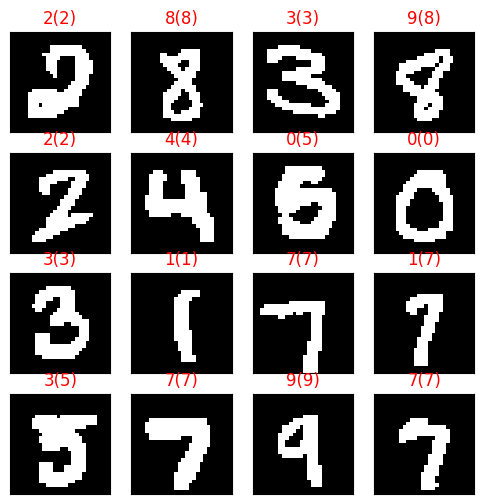

In [63]:
# 绘制图形 与 预测的标签
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
startInd = 400
for row in range(4):
    for col in range(4):
        axes[row, col].imshow(testData[startInd + 4*row+col], cmap='gray', vmin=0, vmax=1)
        label = testLabel[startInd + 4*row+col].item()
        axes[row, col].set_title(f'{testPredList[startInd + 4*row+col]}({label})', color='red')
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

### 1.3 计算模型参数

In [64]:
trainPredArray = np.array(trainPredList).reshape(-1, 1)
accTrain = (np.array(trainPredList).reshape(-1, 1) == trainLabel).sum() / trainLabel.shape[0]
print("MNIST 朴素贝叶斯分类器 在训练集的正确率 accTrain = {}".format(accTrain))


testPredArray = np.array(testPredList).reshape(-1, 1)
accTest = (np.array(testPredList).reshape(-1, 1) == testLabel).sum() / testLabel.shape[0]
print("MNIST 朴素贝叶斯分类器 在测试集的正确率 accTrain = {}".format(accTest))


MNIST 朴素贝叶斯分类器 在训练集的正确率 accTrain = 0.8428
MNIST 朴素贝叶斯分类器 在测试集的正确率 accTrain = 0.818


### 1.4 生成模型

统计出的后验概率其实对应着各类分布的 “知识”, 可以将模型学到的每一个类的数据分布情况给绘制出来

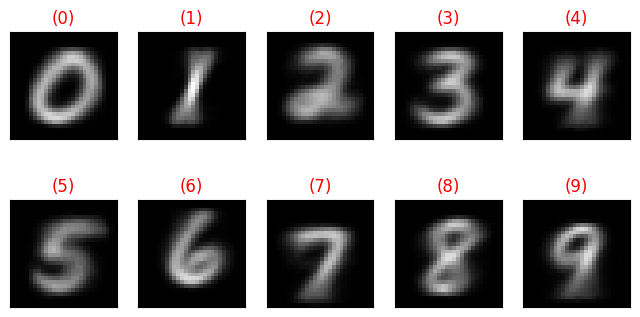

In [65]:
# 绘制图形 与 预测的标签
fig, axes = plt.subplots(2, 5, figsize=(8, 4))

for row in range(2):
    for col in range(5):
        cla = 5*row+col
        
        ## TODO:
        ## ------------- 请在以下填入代码 ------------- ##
        # 取出类别cla的类条件概率（p(x=1|y=cla)），形状为784维
        templateData = conditionProbList[cla].copy()
        # 将784维特征重塑为28×28的图片维度（匹配MNIST原始尺寸）
        templateData = templateData.reshape(28, 28)
        ## ------------- 请在以上填入代码 ------------- ##
        
        axes[row, col].imshow(templateData, cmap='gray', vmin=0, vmax=1)
        axes[row, col].set_title(f'({cla})', color='red')
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

根据已经学习到的知识，可以从类条件概率中的每一位进行采样，生成一个模型学到的各类的图片。

In [66]:
genClassLabels = list(range(10))
genDataList = []

# 设置随机种子（保证采样结果可复现）
np.random.seed(42)

for gLabel in genClassLabels:
    genData = np.zeros(28*28)
    
    ## TODO:
    ## ------------- 请在以下填入代码 ------------- ##
    # 取出当前类别gLabel的类条件概率（p(x_j=1|y=gLabel)，784维）
    condProb = conditionProbList[gLabel]
    
    # 对每个像素维度，基于类条件概率随机采样（伯努利采样）
    # 原理：p=condProb[j] → 采样结果为1的概率是p，0的概率是1-p
    for j in range(28*28):
        genData[j] = np.random.choice([0, 1], p=[1 - condProb[j], condProb[j]])
    ## ------------- 请在以上填入代码 ------------- ##

    genData = genData.reshape((28, 28))
    genDataList.append(genData)

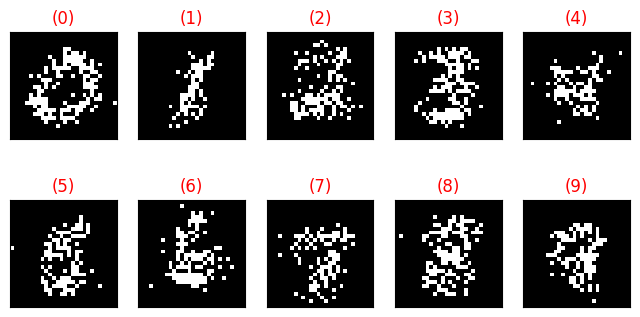

In [67]:
# 绘制图形 与 预测的标签
fig, axes = plt.subplots(2, 5, figsize=(8, 4))

for row in range(2):
    for col in range(5):
        axes[row, col].imshow(genDataList[5*row+col], cmap='gray', vmin=0, vmax=1)
        label = genClassLabels[5*row+col]
        axes[row, col].set_title(f'({label})', color='red')
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])


## 2. 软件缺陷预测

随着软件工业的迅猛发展，软件质量的重要性日益凸显。软件缺陷是影响软件质量的主要因素之一，不仅可能导致系统故障，还可能引发严重的经济和社会后果。因此，如何有效地预测和预防软件缺陷成为了软件工程领域的研究热点之一。

**软件缺陷预测 (Software Defect Prediction，SDP)** 通过使用各种数据挖掘和机器学习方法，从历史项目数据中识别出可能存在缺陷的代码模块，从而帮助开发者在软件发布前进行修复，以减少发布后的错误发生率。

### 2.1 软件缺陷数据集

在 SDData 文件夹目录下，包括 CM1, JM1, ..., PC1, PC2, ..., PC5等数据集。



In [68]:
# 导入相应库函数
import os
import numpy as np
import pandas as pd
from scipy.io import arff

#### 编码
def mapit(vector):

    s = np.unique(vector)

    mapping = pd.Series([x[0] for x in enumerate(s)], index = s)
    vector=vector.map(mapping)
    return vector

### 2.2 读取数据

以 CM1 数据集为例。

In [69]:
# 数据文件路径、文件名
directory, fileName = 'SDData', 'CM1'

data, meta = arff.loadarff(f'{directory}/{fileName}.arff')
X =  pd.DataFrame(data)         # 原始数据

y = X['Defective']
y = mapit(y)                    # 标签编码
del X['Defective']

In [70]:
X

,LOC_BLANK,BRANCH_COUNT,CALL_PAIRS,LOC_CODE_AND_COMMENT,LOC_COMMENTS,CONDITION_COUNT,CYCLOMATIC_COMPLEXITY,CYCLOMATIC_DENSITY,DECISION_COUNT,DECISION_DENSITY,...,MULTIPLE_CONDITION_COUNT,NODE_COUNT,NORMALIZED_CYLOMATIC_COMPLEXITY,NUM_OPERANDS,NUM_OPERATORS,NUM_UNIQUE_OPERANDS,NUM_UNIQUE_OPERATORS,NUMBER_OF_LINES,PERCENT_COMMENTS,LOC_TOTAL
0,9.0,5.0,3.0,2.0,2.0,8.0,3.0,0.16,4.0,2.00,...,4.0,10.0,0.10,36.0,66.0,21.0,17.0,31.0,19.05,19.0
1,19.0,3.0,1.0,2.0,0.0,4.0,2.0,0.06,2.0,2.00,...,2.0,23.0,0.04,66.0,69.0,34.0,12.0,55.0,5.71,35.0
2,0.0,9.0,0.0,0.0,0.0,10.0,5.0,0.56,2.0,5.00,...,7.0,9.0,0.50,10.0,21.0,7.0,9.0,10.0,0.00,9.0
3,2.0,15.0,2.0,1.0,9.0,24.0,8.0,0.19,10.0,2.40,...,12.0,18.0,0.15,67.0,120.0,43.0,19.0,54.0,19.61,42.0
4,5.0,5.0,1.0,0.0,0.0,8.0,3.0,0.15,4.0,2.00,...,4.0,9.0,0.12,25.0,46.0,17.0,14.0,26.0,0.00,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
322,8.0,7.0,0.0,2.0,14.0,10.0,4.0,0.24,4.0,2.50,...,5.0,9.0,0.17,19.0,33.0,11.0,17.0,23.0,51.61,17.0
323,49.0,41.0,14.0,16.0,37.0,78.0,21.0,0.28,38.0,2.05,...,39.0,85.0,0.13,319.0,502.0,96.0,45.0,163.0,46.90,76.0
324,17.0,21.0,7.0,0.0,8.0,36.0,11.0,0.20,16.0,2.25,...,18.0,44.0,0.14,88.0,129.0,41.0,25.0,81.0,12.70,55.0
325,1.0,3.0,4.0,0.0,3.0,4.0,2.0,0.11,2.0,2.00,...,2.0,8.0,0.08,20.0,42.0,17.0,16.0,24.0,13.64,19.0


In [71]:
y

0      0
1      0
2      0
3      0
4      0
      ..
322    0
323    0
324    0
325    0
326    0
Name: Defective, Length: 327, dtype: int64

#### 2.3 训练集 / 测试集 划分

为了测试模型性能，防止模型过拟合，需要将原始数据 $X$ 与 $y$ 进行划分。在训练集上训练模型，然后在测试集上评价模型。

In [72]:

from sklearn.model_selection import train_test_split
# 训练集 (80%), 测试集 (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [73]:
X_train

,LOC_BLANK,BRANCH_COUNT,CALL_PAIRS,LOC_CODE_AND_COMMENT,LOC_COMMENTS,CONDITION_COUNT,CYCLOMATIC_COMPLEXITY,CYCLOMATIC_DENSITY,DECISION_COUNT,DECISION_DENSITY,...,MULTIPLE_CONDITION_COUNT,NODE_COUNT,NORMALIZED_CYLOMATIC_COMPLEXITY,NUM_OPERANDS,NUM_OPERATORS,NUM_UNIQUE_OPERANDS,NUM_UNIQUE_OPERATORS,NUMBER_OF_LINES,PERCENT_COMMENTS,LOC_TOTAL
155,84.0,37.0,10.0,44.0,76.0,66.0,19.0,0.13,32.0,2.06,...,33.0,65.0,0.06,264.0,421.0,100.0,50.0,306.0,54.30,145.0
223,67.0,29.0,10.0,27.0,41.0,56.0,15.0,0.13,28.0,2.00,...,28.0,63.0,0.07,192.0,274.0,32.0,19.0,228.0,42.50,119.0
64,22.0,29.0,0.0,8.0,35.0,44.0,15.0,0.28,16.0,2.75,...,22.0,32.0,0.13,110.0,129.0,37.0,15.0,112.0,48.31,54.0
115,9.0,7.0,4.0,2.0,13.0,12.0,4.0,0.18,6.0,2.00,...,6.0,14.0,0.09,38.0,84.0,25.0,19.0,45.0,42.86,22.0
151,22.0,58.0,13.0,12.0,33.0,78.0,32.0,0.19,36.0,2.17,...,39.0,94.0,0.14,163.0,325.0,104.0,29.0,228.0,21.95,172.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,15.0,7.0,4.0,0.0,21.0,12.0,4.0,0.10,6.0,2.00,...,6.0,23.0,0.05,117.0,130.0,42.0,17.0,78.0,33.87,41.0
12,13.0,9.0,5.0,12.0,16.0,16.0,5.0,0.14,8.0,2.00,...,8.0,18.0,0.07,38.0,69.0,20.0,15.0,67.0,52.83,37.0
249,1.0,7.0,1.0,1.0,0.0,8.0,4.0,0.25,2.0,4.00,...,4.0,9.0,0.22,18.0,37.0,12.0,16.0,18.0,6.25,16.0
290,5.0,3.0,9.0,0.0,6.0,4.0,2.0,0.07,2.0,2.00,...,2.0,13.0,0.05,57.0,94.0,33.0,17.0,42.0,16.67,30.0


In [74]:
X_test

,LOC_BLANK,BRANCH_COUNT,CALL_PAIRS,LOC_CODE_AND_COMMENT,LOC_COMMENTS,CONDITION_COUNT,CYCLOMATIC_COMPLEXITY,CYCLOMATIC_DENSITY,DECISION_COUNT,DECISION_DENSITY,...,MULTIPLE_CONDITION_COUNT,NODE_COUNT,NORMALIZED_CYLOMATIC_COMPLEXITY,NUM_OPERANDS,NUM_OPERATORS,NUM_UNIQUE_OPERANDS,NUM_UNIQUE_OPERATORS,NUMBER_OF_LINES,PERCENT_COMMENTS,LOC_TOTAL
44,3.0,3.0,2.0,0.0,2.0,4.0,2.0,0.22,2.0,2.00,...,2.0,6.0,0.13,11.0,15.0,9.0,9.0,15.0,18.18,9.0
68,35.0,21.0,9.0,9.0,59.0,36.0,11.0,0.12,16.0,2.25,...,18.0,55.0,0.06,190.0,285.0,68.0,32.0,186.0,45.33,91.0
13,8.0,5.0,2.0,2.0,19.0,8.0,3.0,0.14,4.0,2.00,...,4.0,9.0,0.06,21.0,43.0,18.0,18.0,50.0,51.22,22.0
175,17.0,20.0,3.0,5.0,0.0,14.0,15.0,0.22,6.0,2.33,...,7.0,27.0,0.17,79.0,183.0,39.0,35.0,86.0,7.35,68.0
316,12.0,7.0,8.0,3.0,3.0,12.0,4.0,0.12,6.0,2.00,...,6.0,23.0,0.08,58.0,64.0,21.0,15.0,49.0,16.67,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,27.0,13.0,4.0,4.0,33.0,6.0,10.0,0.24,2.0,3.00,...,3.0,17.0,0.10,54.0,88.0,30.0,29.0,103.0,49.33,42.0
254,16.0,7.0,3.0,0.0,15.0,12.0,4.0,0.16,6.0,2.00,...,6.0,13.0,0.07,37.0,60.0,14.0,17.0,57.0,37.50,25.0
61,9.0,7.0,1.0,6.0,10.0,12.0,4.0,0.18,6.0,2.00,...,6.0,12.0,0.10,41.0,68.0,19.0,24.0,42.0,50.00,22.0
32,1.0,3.0,4.0,0.0,6.0,4.0,2.0,0.05,2.0,2.00,...,2.0,8.0,0.04,91.0,119.0,59.0,18.0,50.0,12.50,42.0


#### 2.4 使用朴素贝叶斯分类器预测 SD 数据集 

采用sklearn.naive_bayes里面的GaussianNB库函数训练模型，并对测试集上的数据进行测试，输出 混淆矩阵 (confusion matrix) 和 准确度 (accuracy)。

In [75]:
from sklearn.naive_bayes import GaussianNB 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
np.set_printoptions(precision = 3)

classifier = GaussianNB()
classifier.fit(X_train.values, y_train.values)
y_pred = classifier.predict(X_test.values)

for i, prediction in enumerate(y_pred[:2]):
    print('Prediction: %s. Real: %s.' % (prediction, y_test.values[i]))
    print(f'Message: {np.round(X_test.values[i], 3)}\n')

Prediction: 0. Real: 0.
Message: [3.000e+00 3.000e+00 2.000e+00 0.000e+00 2.000e+00 4.000e+00 2.000e+00
 2.200e-01 2.000e+00 2.000e+00 2.000e+00 1.000e+00 6.000e+00 1.000e+00
 0.000e+00 9.000e+00 0.000e+00 1.971e+01 5.500e+00 5.963e+02 4.000e-02
 2.600e+01 1.800e-01 3.313e+01 1.084e+02 5.000e-01 1.000e+00 2.000e+00
 6.000e+00 1.300e-01 1.100e+01 1.500e+01 9.000e+00 9.000e+00 1.500e+01
 1.818e+01 9.000e+00]

Prediction: 1. Real: 1.
Message: [3.500e+01 2.100e+01 9.000e+00 9.000e+00 5.900e+01 3.600e+01 1.100e+01
 1.200e-01 1.600e+01 2.250e+00 1.000e+01 9.100e-01 6.400e+01 3.000e+00
 2.000e-01 8.200e+01 3.000e+00 7.059e+01 4.471e+01 1.411e+05 1.050e+00
 4.750e+02 2.000e-02 7.838e+03 3.156e+03 2.700e-01 1.000e+01 1.800e+01
 5.500e+01 6.000e-02 1.900e+02 2.850e+02 6.800e+01 3.200e+01 1.860e+02
 4.533e+01 9.100e+01]



In [76]:
# 输出准确度和混淆矩阵
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred))

Accuracy: 0.8181818181818182
Confusion matrix:
 [[50  5]
 [ 7  4]]


#### 2.5 使用交叉验证

交叉验证（Cross Validation）是一种统计学方法，用于评估机器学习模型在独立数据集上的性能。它主要用于模型选择，即在一组模型中选择最佳模型，并且能够有效地避免过拟合。交叉验证通过将数据集分割成多个小子集来实现，其中一部分用于训练模型，另一部分用于测试模型。

$$
Precision = \frac{TP}{TP+FP}
$$


$$
Recall = \frac{TP}{TP+FN}
$$

In [77]:
from sklearn.model_selection import cross_val_score

# step 1 利用5折交叉验证对classifier进行训练，输出accuracy
scores = cross_val_score(classifier, X, y, cv = 5, scoring = 'accuracy')
print('Accuracy:', np.mean(scores), scores)

# step 2 利用5折交叉验证对classifier进行训练，输出precision
## TODO:
## ------------- 请在以下填入代码 ------------- ##
# precision：精确率（针对二分类，需指定pos_label；默认正类为1）
precisions = cross_val_score(classifier, X, y, cv=5, scoring='precision')                                       
print('Precision:', np.mean(precisions), precisions)

# step 3 利用5折交叉验证对classifier进行训练，输出recall
## TODO:
## ------------- 请在以下填入代码 ------------- ##
# recall：召回率（针对二分类，正类为1）
recalls = cross_val_score(classifier, X, y, cv=5, scoring='recall')
print('Recall:', np.mean(recalls), recalls)

# step 4 利用5折交叉验证对classifier进行训练，输出f1
## TODO:
## ------------- 请在以下填入代码 ------------- ##
# f1：F1分数（精确率和召回率的调和平均，正类为1）
f1s = cross_val_score(classifier, X, y, cv=5, scoring='f1')
print('F1:', np.mean(f1s), f1s)

Accuracy: 0.7739393939393938 [0.652 0.818 0.815 0.8   0.785]
Precision: 0.20969696969696966 [0.182 0.333 0.333 0.    0.2  ]
Recall: 0.3055555555555555 [0.444 0.333 0.5   0.    0.25 ]
F1: 0.24272401433691754 [0.258 0.333 0.4   0.    0.222]


- 精确率衡量的是在所有检索出的样本（程序识别为“真”）中有多少是真正所期望被检索（真实为真）出的样本；

- 召回率衡量的则是在所有被期望检索（真实为真）出的样本中，到底检索出了多少样本。

#### 2.6 绘制PR曲线

精确率和召回率之间总体上（不是绝对）存在着某种相互制约的关系，即类似于此消彼长的情况。

可能模型某些时候取得了较高的召回率但是精确率却很低，也可能是取得了较高的精确率但召回率却很低。

所以，在实际情况中我们会根据需要来选择不同的侧重点，当然最理想的情况就是在取得高召回率的同时还能保持较高的精确率。

In [78]:
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from matplotlib import pyplot as plt

Text(0.5, 1.0, '2-class Precision-Recall curve: AP=0.27')

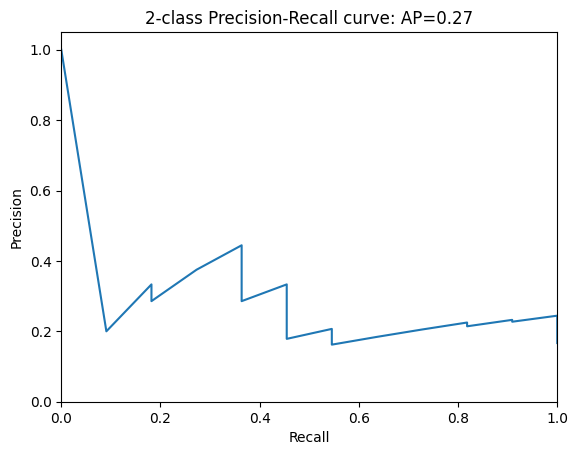

In [79]:
classifier = GaussianNB()
classifier.fit(X_train, y_train)

# step 1 调用predict_proba方法得到测试集的预测概率
y_pred_array = classifier.predict_proba(X_test)
y_pred_prob = y_pred_array[:, 1]

average_precision = average_precision_score(y_test, y_pred_prob)

# step 2 调用precision_recall_curve计算P-R曲线上各点的precision和recall

## TODO:
## ------------- 请在以下填入代码 ------------- ##
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

# step 3 调用matplotlib.pyplot的plot方法画P-R曲线
plt.plot(recall, precision)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('2-class Precision-Recall curve: AP={0:0.2f}'.format(average_precision))

可以看出，模型的表现并不是很好。有一部分原因是由于数据是“不平衡”的数据集，也就是说，绝大多数数据的标签都是 0 。因此模型的预测值会更倾向于预测 0。

#### 2.7 ROC 曲线

ROC坐标系中纵轴为 TPR（真阳率/命中率/召回率）最大值为 1，横轴为 FPR（假阳率/误判率）最大值为 1，虚线为基准线（最低标准），蓝色的曲线就是 ROC 曲线。其中 ROC 曲线距离基准线越远，则说明该模型的预测效果越好。(TPR: True positive rate; FPR: False positive rate)

Text(0.5, 0, 'Fall-out')

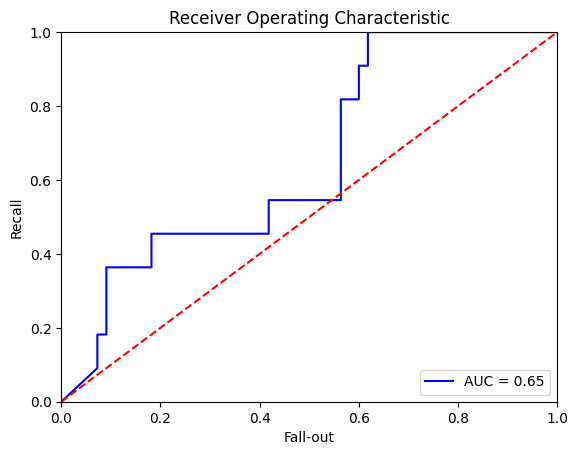

In [80]:
from sklearn.metrics import roc_curve, auc

# step 1 创建naive_bayes对象classifier, 用训练集训练classifier
#        利用训练好的classifier对测试集进行预测,得到预测概率值
classifier = GaussianNB()
classifier.fit(X_train, y_train)
y_pred_array = classifier.predict_proba(X_test)
y_pred_prob = y_pred_array[:, 1]


# step 2 根据真实标签和预测概率值调用roc_curve计算false_positive_rate、recall和thresholds
#        调用auc计算ROC曲线下方的面积大小roc_auc

## TOD:
## ------------- 请在以下填入代码 ------------- ##
false_positive_rate, recall, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(false_positive_rate, recall)

# step 3 画ROC曲线
plt.plot(false_positive_rate, recall, 'b', label='AUC = %0.2f' %roc_auc)

plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.ylabel('Recall')
plt.xlabel('Fall-out')